1 Setup libraries

In [ ]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from encoding import encode_columns
import matplotlib.pyplot as plt

file_path = r"C:\Users\ADMIN\Documents\Algorithm_Inno\ML\data\data.json"

2 Load dataset

In [5]:

df = pd.read_json(file_path)
df.head()



,Transaction ID,Sender Account ID,Receiver Account ID,Transaction amount,Timestamp,Transaction Detail,Geological,Device Use,Date of Birth,Gender,Location,Account balance,Transaction Count,Working Status,Salary (per month)
0,TXN_300001,ACC_04483,REC_7570,458000,2025-02-27 21:37:00,Starbucks,HCMC - VN,Android Phone,1996-08-12,Male,Hai Phong,"79,000,000",3,Employed,"13,000,000"
1,TXN_300002,ACC_04770,REC_8777,203000,2025-04-21 22:53:00,Starbucks,Can Tho - VN,Samsung S23,2004-06-17,Female,Bac Ninh,"29,000,000",2,Employed,"43,000,000"
2,TXN_300003,ACC_06821,REC_3980,1392000,2025-12-17 07:15:00,Restaurant,Hanoi - VN,Samsung S23,1992-05-07,Female,Hue,"140,000,000",4,Employed,"45,000,000"
3,TXN_300004,ACC_08825,REC_7662,11046000,2025-06-25 07:22:00,Monthly Salary,HCMC - VN,iPhone 15,1984-04-25,Female,Can Tho,"21,000,000",2,Employed,"29,000,000"
4,TXN_300005,ACC_03949,REC_6068,120000,2025-12-16 10:09:00,Restaurant,HCMC - VN,Web Browser,1976-10-05,Female,Bac Ninh,"468,000,000",4,Unemployed,0


if 'Date of Birth' in df.columns:
    df['Date of Birth'] = pd.to_datetime(df['Date of Birth'], errors='coerce')
    df['Age'] = (datetime(2026, 3, 5) - df['Date of Birth']).dt.days // 365

feature_cols = [
    'Salary (per month)', 'Account balance', 'Transaction Count',
    'Working Status', 'Hour', 'DayOfWeek', 'Transaction Detail',
    'Location', 'Geological', 'Gender', 'Age',
]
    
    
available = [col for col in feature_cols if col in df.columns]
X = df[available].copy()
y = df['Transaction amount']

# Encoding using shared module
X, _ = encode_columns(X)

X = X.fillna(X.median(numeric_only=True))


In [8]:
if 'Date of Birth' in df.columns:
    df['Date of Birth'] = pd.to_datetime(df['Date of Birth'], errors='coerce')
    df['Age'] = (datetime(2026, 3, 5) - df['Date of Birth']).dt.days // 365

feature_cols = [
    'Salary (per month)', 'Account balance', 'Transaction Count',
    'Working Status', 'Hour', 'DayOfWeek', 'Transaction Detail',
    'Location', 'Geological', 'Gender', 'Age',
]
    
    
available = [col for col in feature_cols if col in df.columns]
X = df[available].copy()
y = df['Transaction amount']

for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X = X.fillna(X.median(numeric_only=True))



Train model

In [9]:
   
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
    

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Evaluate

In [18]:
preds = model.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, preds):.2f}")
print(f"MSE: {mean_squared_error(y_test, preds):.2f}")
print(f"R2:  {r2_score(y_test, preds):.4f}")

importances = sorted(zip(available, model.feature_importances_), key=lambda x: x[1], reverse=True)
print("\nFeature Importances:")
for name, score in importances:
    print(f"  {name:<25} {score:.4f}")


MAE: 22448678.26
MSE: 4780876148429367.00
R2:  0.8346

Feature Importances:
  Geological                0.4360
  Transaction Detail        0.4191
  Account balance           0.0638
  Salary (per month)        0.0290
  Age                       0.0192
  Location                  0.0159
  Transaction Count         0.0116
  Gender                    0.0040
  Working Status            0.0013


Visualization


Text(0.5, 1.0, 'Actual vs Predicted Transaction Amount')

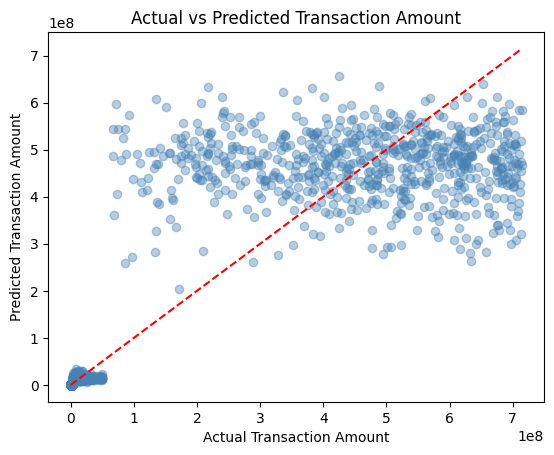

In [ ]:
errors = y_test.values - preds

# 1. Actual vs Predicted
plt.figure()
plt.scatter(y_test, preds, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Transaction Amount')
plt.ylabel('Predicted Transaction Amount')
plt.title('Actual vs Predicted Transaction Amount')

Text(0.5, 1.0, 'Feature Importances (Customer Habits)')

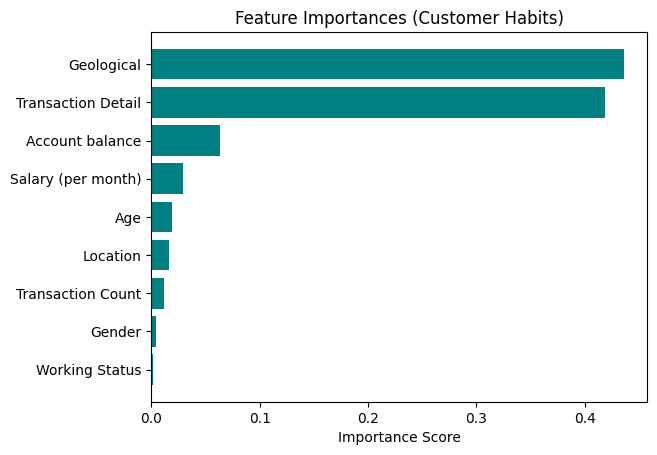

In [19]:
# 2. Feature Importances
plt.figure()
importances = sorted(zip(available, model.feature_importances_), key=lambda x: x[1])
names, scores = zip(*importances)
plt.barh(names, scores, color='teal')
plt.xlabel('Importance Score')
plt.title('Feature Importances (Customer Habits)')


Text(0.5, 1.0, 'Prediction Error Distribution')

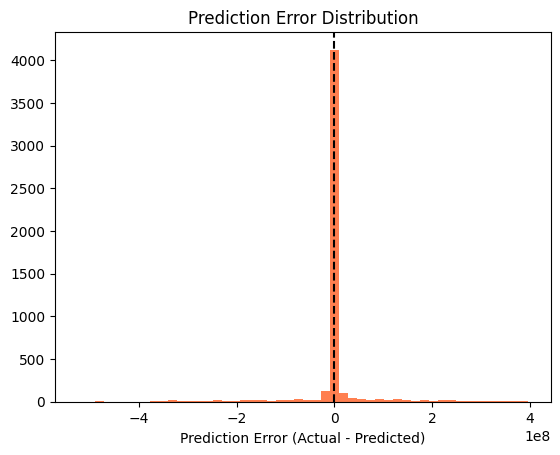

In [15]:
# 3. Prediction Error Distribution
plt.figure()
plt.hist(errors, bins=50, color='coral')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.title('Prediction Error Distribution')


Text(0.5, 1.0, 'Residuals vs Predicted Amount')

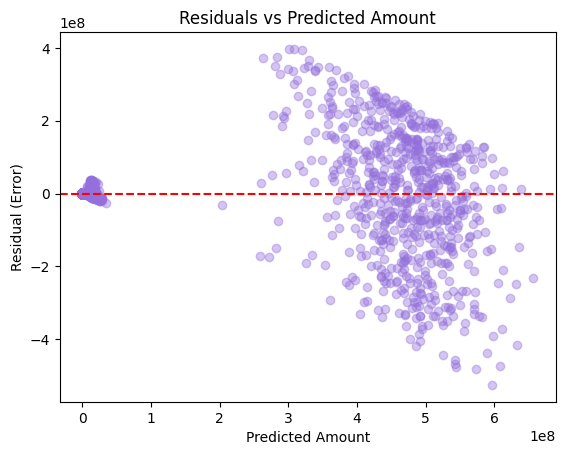

In [17]:
# 4. Residuals vs Predicted
plt.figure()
plt.scatter(preds, errors, alpha=0.4, color='mediumpurple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Amount')
plt.ylabel('Residual (Error)')
plt.title('Residuals vs Predicted Amount')

